# Walmart Sales Forecasting Project

# Notebook 06 – Model Building

## Objective

Train multiple machine learning models using the feature-engineered dataset and prepare them for evaluation.

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.ensemble import RandomForestRegressor

In [2]:
df = pd.read_excel("../data/processed/sales_feature_engineered.xlsx")

In [3]:
print(df.columns)

Index(['Order Date', 'Sales', 'Year', 'Quarter', 'Month', 'Week', 'Day',
       'DayOfWeek', 'IsWeekend', 'Lag_1', 'Lag_7', 'Lag_30', 'Rolling_Mean_7',
       'Rolling_Mean_30', 'Rolling_STD_7', 'Expanding_Mean', 'Month_Sin',
       'Month_Cos', 'Day_Sin', 'Day_Cos'],
      dtype='str')


In [4]:
df.head()

,Order Date,Sales,Year,Quarter,Month,Week,Day,DayOfWeek,IsWeekend,Lag_1,Lag_7,Lag_30,Rolling_Mean_7,Rolling_Mean_30,Rolling_STD_7,Expanding_Mean,Month_Sin,Month_Cos,Day_Sin,Day_Cos
0,2011-02-06,0.00,2011,1,2,5,6,6,1,134.384,0.000,19.44,76.358857,105.437633,109.021650,102.663516,0.866025,0.5,-0.781831,0.623490
1,2011-02-07,0.00,2011,1,2,6,7,0,0,0.000,0.000,0.00,76.358857,105.437633,109.021650,99.455281,0.866025,0.5,0.000000,1.000000
2,2011-02-08,0.00,2011,1,2,6,8,1,0,0.000,290.666,0.00,34.835143,105.437633,56.491758,96.441485,0.866025,0.5,0.781831,0.623490
3,2011-02-09,14.56,2011,1,2,6,9,2,0,0.000,0.000,0.00,36.915143,105.922967,55.249769,94.033206,0.866025,0.5,0.974928,-0.222521
4,2011-02-10,0.00,2011,1,2,6,10,3,0,14.560,12.350,0.00,35.150857,105.922967,56.351152,91.346543,0.866025,0.5,0.433884,-0.900969


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1425 entries, 0 to 1424
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Order Date       1425 non-null   datetime64[us]
 1   Sales            1425 non-null   float64       
 2   Year             1425 non-null   int64         
 3   Quarter          1425 non-null   int64         
 4   Month            1425 non-null   int64         
 5   Week             1425 non-null   int64         
 6   Day              1425 non-null   int64         
 7   DayOfWeek        1425 non-null   int64         
 8   IsWeekend        1425 non-null   int64         
 9   Lag_1            1425 non-null   float64       
 10  Lag_7            1425 non-null   float64       
 11  Lag_30           1425 non-null   float64       
 12  Rolling_Mean_7   1425 non-null   float64       
 13  Rolling_Mean_30  1425 non-null   float64       
 14  Rolling_STD_7    1425 non-null   float64       
 15

In [6]:
df.shape

(1425, 20)

In [7]:
X = df.drop(columns=["Order Date", "Sales"])

y = df["Sales"]

In [8]:
print(X.shape)
print(y.shape)

(1425, 18)
(1425,)


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

In [10]:
print(X_train.shape)
print(X_test.shape)

(1140, 18)
(285, 18)


In [11]:
baseline_prediction = X_test["Lag_1"]

In [12]:
lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](18,)","[ 16.34, -24.12, -28.96,..., 9.49, -98.05,-184.67]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](18,)","['Year','Quarter','Month',...,'Month_Cos','Day_Sin','Day_Cos']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-3.255e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,18
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(18)


In [13]:
lr_predictions = lr_model.predict(X_test)

In [14]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [15]:
rf_predictions = rf_model.predict(X_test)

In [16]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
10,Rolling_Mean_7,0.223490
12,Rolling_STD_7,0.169545
8,Lag_7,0.090607
11,Rolling_Mean_30,0.080299
13,Expanding_Mean,0.075163
7,Lag_1,0.067442
4,Day,0.059391
5,DayOfWeek,0.053027
9,Lag_30,0.048104
3,Week,0.031862


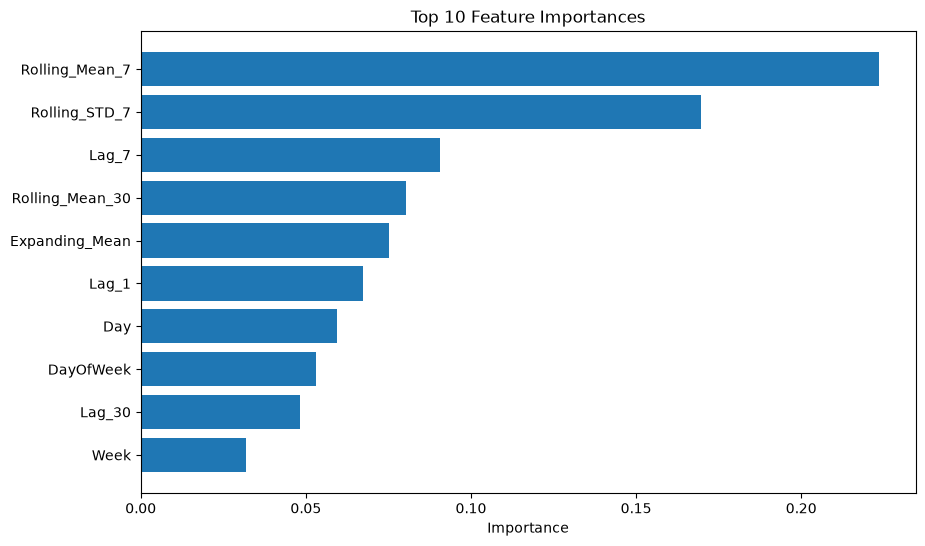

In [17]:
import matplotlib.pyplot as plt

top10 = feature_importance.head(10)

plt.figure(figsize=(10,6))
plt.barh(top10["Feature"], top10["Importance"])
plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.show()

In [18]:
import joblib

joblib.dump(lr_model, "../models/linear_regression.pkl")

joblib.dump(rf_model, "../models/random_forest.pkl")

['../models/random_forest.pkl']

# Business Insights

## Key Findings

- Multiple machine learning models were trained using engineered features.
- Random Forest provides feature importance, helping identify the most influential predictors of sales.
- The models are now ready for quantitative evaluation in the next notebook.

In [19]:
import joblib

joblib.dump(lr_model, "../models/linear_regression.pkl")
joblib.dump(rf_model, "../models/random_forest.pkl")

['../models/random_forest.pkl']

In [21]:
import os

print(os.listdir("../models"))

['linear_regression.pkl', 'random_forest.pkl']


In [38]:
import os

print(os.getcwd())

/Users/karishma/Documents/Sales_Forecasting_Project/notebooks
